In [3]:
import numpy as np
import pandas as pd
import seaborn as sb
import tensorflow as tf
import matplotlib.pyplot as pt

In [4]:
sb.set_style('white')

In [5]:
df = pd.read_csv('./DATASETS/heart.csv')

In [6]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


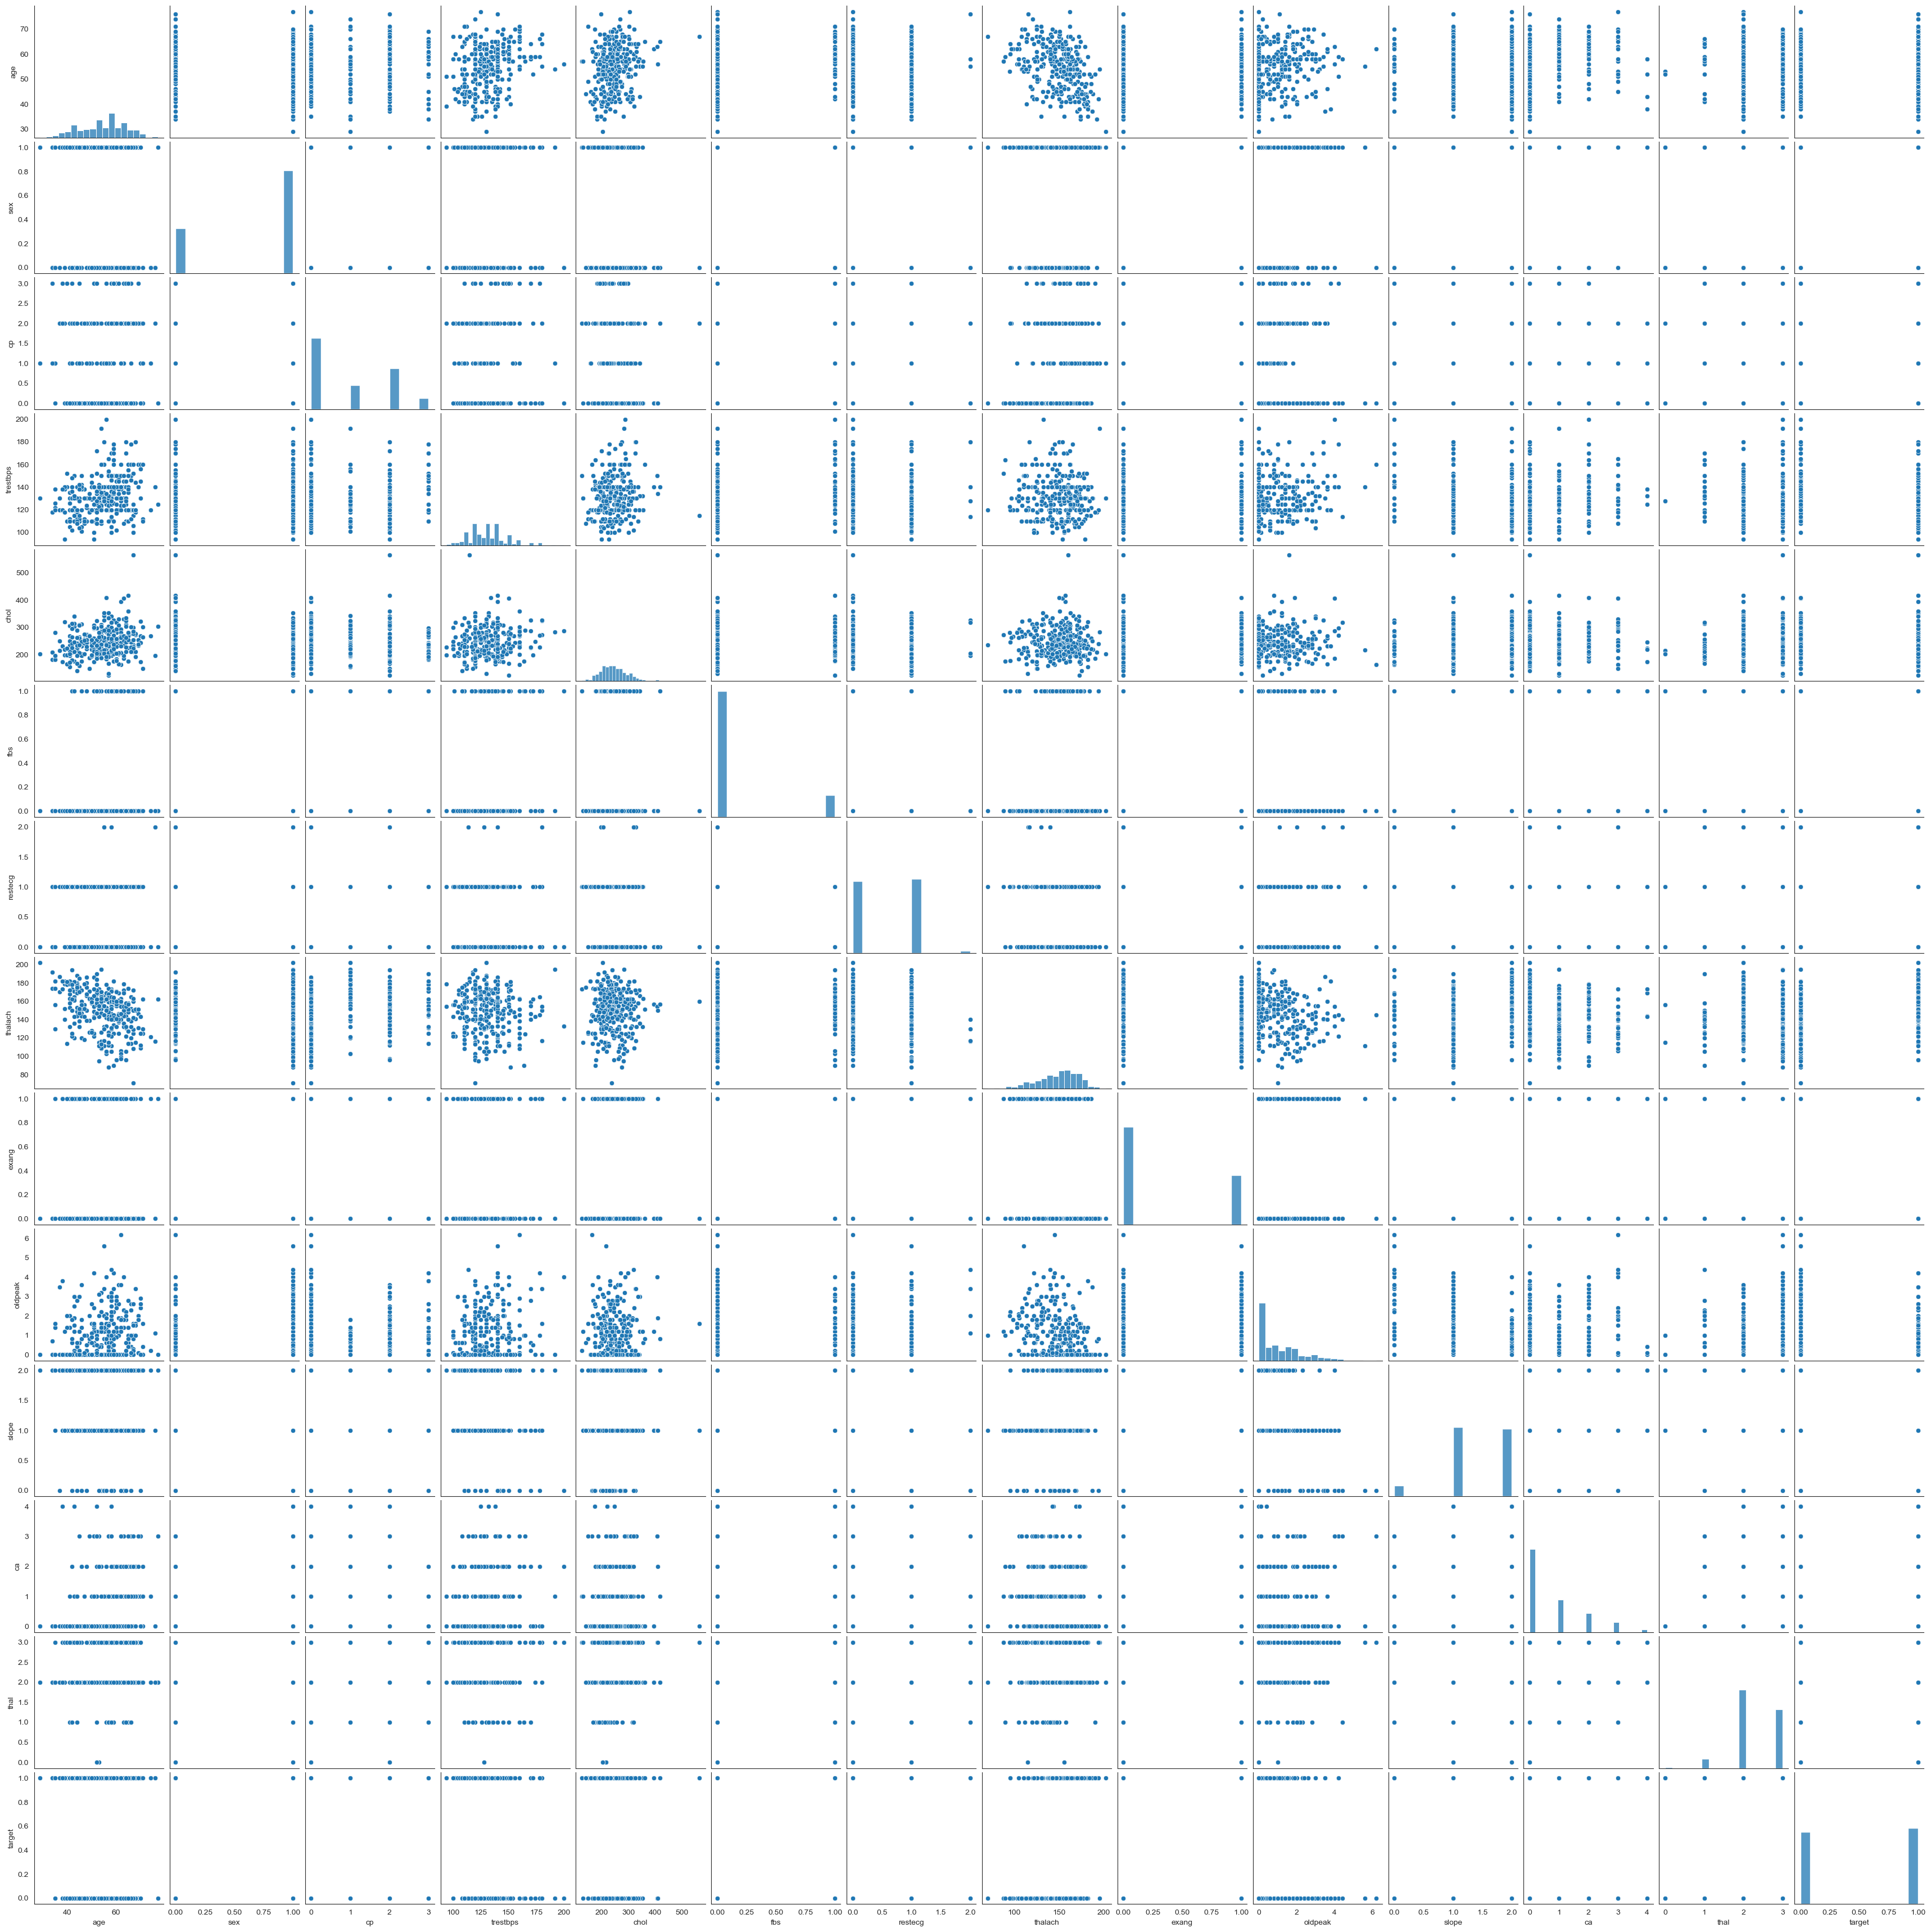

In [7]:
sb.pairplot(df)

In [8]:
df.shape

(1025, 14)

<Axes: xlabel='target', ylabel='count'>

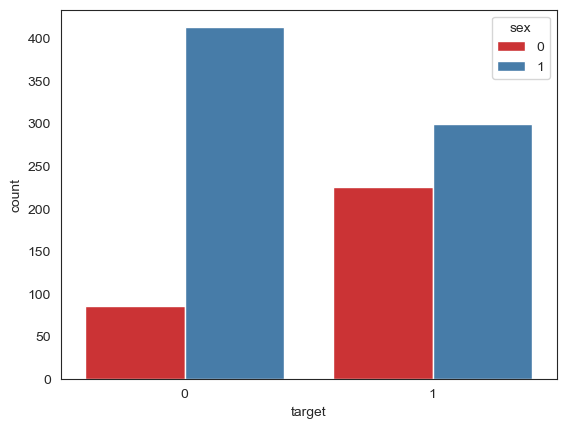

In [9]:
sb.countplot(x='target', data=df, palette='Set1', hue='sex')

<Axes: >

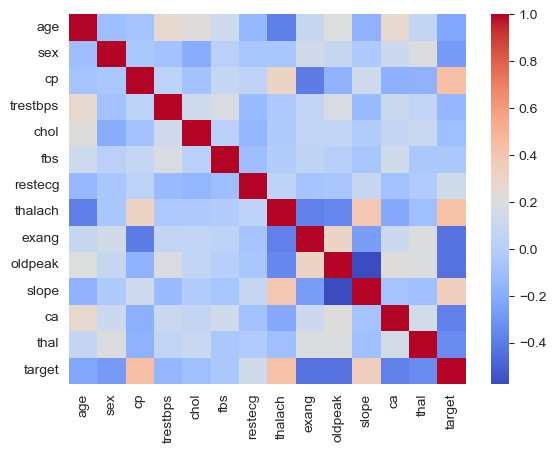

In [11]:
sb.heatmap(df.corr(), cmap='coolwarm')

**Let's scale the dataset and train and evalaute the model**

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X = df.drop('target', axis=1)
y = df['target']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

In [15]:
from sklearn.preprocessing import MinMaxScaler

In [16]:
scaler = MinMaxScaler()

In [17]:
scaler.fit(X_train)

MinMaxScaler()

In [18]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
X_train[0]

array([0.625     , 1.        , 1.        , 0.79245283, 0.32876712,
       0.        , 0.        , 0.5648855 , 0.        , 0.67741935,
       0.        , 0.        , 1.        ])

In [20]:
X_test[0]

array([0.4375    , 1.        , 0.        , 0.47169811, 0.16894977,
       0.        , 0.        , 0.41984733, 1.        , 0.14516129,
       0.5       , 0.        , 1.        ])

In [21]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [25]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [26]:
model.fit(X_train, y_train, epochs=400, validation_data=(X_test, y_test))

Epoch 1/400
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5312 - loss: 0.6894 - val_accuracy: 0.5875 - val_loss: 0.6584
Epoch 2/400
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7409 - loss: 0.6254 - val_accuracy: 0.7315 - val_loss: 0.6128
Epoch 3/400
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8047 - loss: 0.5723 - val_accuracy: 0.7665 - val_loss: 0.5637
Epoch 4/400
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8086 - loss: 0.5196 - val_accuracy: 0.7938 - val_loss: 0.5131
Epoch 5/400
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8190 - loss: 0.4720 - val_accuracy: 0.7899 - val_loss: 0.4717
Epoch 6/400
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8151 - loss: 0.4320 - val_accuracy: 0.7899 - val_loss: 0.4385
Epoch 7/400
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8268 - loss: 0.4019 - val_accuracy: 0.8016 - val_loss: 0.4052
Epoch 8/400
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8385 - loss: 0.3840 - val_accuracy: 0.7977 - 

In [27]:
losses = pd.DataFrame(model.history.history)

<Axes: >

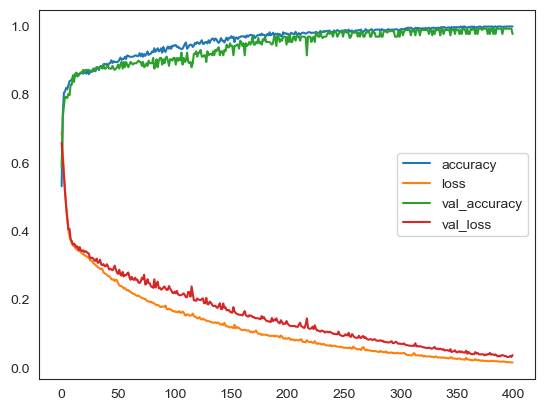

In [28]:
losses.plot()

In [42]:
prediction = model.predict(X_test)

prediction = (prediction > 0.5).astype(int).flatten()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [43]:
from sklearn.metrics import classification_report, accuracy_score

In [44]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       128
           1       1.00      0.95      0.98       129

    accuracy                           0.98       257
   macro avg       0.98      0.98      0.98       257
weighted avg       0.98      0.98      0.98       257



In [45]:
print("Accuracy : ", 100 * accuracy_score(y_test, prediction))

Accuracy :  97.66536964980544


In [52]:
test = pd.DataFrame({
    "Actual" : y_test,
    "Predicted" : prediction
})
test['Correct'] = test['Actual'] == test['Predicted']

In [54]:
test.head(100)

,Actual,Predicted,Correct
909,0,0,True
748,1,1,True
919,0,0,True
975,0,0,True
246,0,0,True
...,...,...,...
846,1,1,True
460,0,0,True
972,1,1,True
162,0,0,True


In [55]:
test.to_csv("predictions.csv", index=False)

In [57]:
test['Correct'].value_counts()

Correct
True     251
False      6
Name: count, dtype: int64